# U-Net for Ultrasound Dehazing (From Scratch)

This notebook implements a U-Net model in PyTorch for image dehazing without using any pretrained weights.

- Dataset root: `Dataset/`
- Expected paired folders: `Dataset/noisy` and `Dataset/clean` (same filenames), or provide a mapping file `Dataset/dataset_mapping.csv` with columns containing the words `noisy` and `clean`.
- Outputs: checkpoints and sample predictions will be written to `checkpoints/unet_dehazing` and `Dataset/visualizations/unet_results`.

You can customize image size, batch size, epochs, etc., in the Config cell.

# Install required packages if missing (safe to re-run).

In [27]:
# Install required packages if missing (safe to re-run).
import sys, subprocess

# Map import names to pip install names when they differ
PIP_NAME = {
    'cv2': 'opencv-python',
    'skimage': 'scikit-image',
}

def ensure(import_name):
    try:
        __import__(import_name)
        return True
    except Exception:
        pkg = PIP_NAME.get(import_name, import_name)
        try:
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])
            __import__(import_name)
            return True
        except Exception as e:
            print(f'Failed to install {import_name} (pip: {pkg}):', e)
            return False

# Core deps
ok = True
for p in ['torch', 'numpy', 'tqdm', 'cv2', 'skimage', 'matplotlib', 'scipy']:
    ok = ensure(p) and ok

if not ok:
    print('Some packages failed to install. You may need to restart the kernel or install manually.')
else:
    print('All required packages are available.')

All required packages are available.


# Imports and device setup

In [28]:
# Imports and device setup
import os
import csv
import math
import random
from glob import glob

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

import cv2
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from scipy import stats

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

# Config

In [29]:
# Config
from dataclasses import dataclass

@dataclass
class Config:
    # dataset_root: str = r"../Dataset" 
    dataset_root: str = r"../Dataset_augmented"
    noisy_dir: str = os.path.join(dataset_root, 'noisy')
    clean_dir: str = os.path.join(dataset_root, 'clean')
    noisy_roi_dir: str = os.path.join(dataset_root, 'noisy_roi')  # ROI masks directory (optional)
    mapping_csv: str = os.path.join(dataset_root, 'dataset_mapping.csv')

    out_dir: str = os.path.join('checkpoints', 'unet_dehazing')
    vis_dir: str = os.path.join('Dataset', 'visualizations', 'unet_results')

    image_size: int = 256      # must be divisible by 32 for U-Net depth=5
    in_channels: int = 1       # using grayscale by default
    out_channels: int = 1
    bilinear: bool = True

    batch_size: int = 8
    num_workers: int = 0       # set >0 if your environment supports it
    epochs: int = 200
    lr: float = 2e-4
    weight_decay: float = 0.0

    val_split: float = 0.1
    seed: int = 42

cfg = Config()

# Resolve dataset_root relative to the notebook location if needed
def resolve_dataset_paths(c):
    if os.path.isabs(c.dataset_root) and os.path.isdir(c.dataset_root):
        root = c.dataset_root
    else:
        candidates = [
            c.dataset_root,
            os.path.join('..', 'Dataset'),
            os.path.join('..', '..', 'Dataset'),
        ]
        root = None
        for cand in candidates:
            if os.path.isdir(cand):
                root = os.path.abspath(cand)
                break
        if root is None:
            # Fallback to initial value (may be non-existent; later code will show diagnostics)
            root = os.path.abspath(c.dataset_root)
    # Update cfg with absolute, consistent paths
    c.dataset_root = root
    c.noisy_dir = os.path.join(root, 'noisy')
    c.clean_dir = os.path.join(root, 'clean')
    c.noisy_roi_dir = os.path.join(root, 'noisy_roi')
    c.mapping_csv = os.path.join(root, 'dataset_mapping.csv')
    # Put visualizations under the resolved dataset root for clarity
    c.vis_dir = os.path.join(root, 'visualizations', 'unet_results')
    return c

cfg = resolve_dataset_paths(cfg)
print('Resolved dataset root to:', cfg.dataset_root)
cfg

Resolved dataset root to: c:\Users\mkhan\Documents\Projects\CSE498\Dehazing\Dataset_augmented


Config(dataset_root='c:\\Users\\mkhan\\Documents\\Projects\\CSE498\\Dehazing\\Dataset_augmented', noisy_dir='c:\\Users\\mkhan\\Documents\\Projects\\CSE498\\Dehazing\\Dataset_augmented\\noisy', clean_dir='c:\\Users\\mkhan\\Documents\\Projects\\CSE498\\Dehazing\\Dataset_augmented\\clean', noisy_roi_dir='c:\\Users\\mkhan\\Documents\\Projects\\CSE498\\Dehazing\\Dataset_augmented\\noisy_roi', mapping_csv='c:\\Users\\mkhan\\Documents\\Projects\\CSE498\\Dehazing\\Dataset_augmented\\dataset_mapping.csv', out_dir='checkpoints\\unet_dehazing', vis_dir='c:\\Users\\mkhan\\Documents\\Projects\\CSE498\\Dehazing\\Dataset_augmented\\visualizations\\unet_results', image_size=256, in_channels=1, out_channels=1, bilinear=True, batch_size=8, num_workers=0, epochs=200, lr=0.0002, weight_decay=0.0, val_split=0.1, seed=42)

# Utils: seeding, dirs, metrics

In [30]:
# Utils: seeding, dirs, metrics
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def ensure_dir(path: str):
    os.makedirs(path, exist_ok=True)

def tensor_to_img(t: torch.Tensor):
    # expects shape (1,H,W) or (H,W) in [0,1]
    t = t.detach().cpu().float()
    if t.ndim == 3 and t.size(0) == 1:
        t = t[0]
    arr = t.numpy()
    arr = np.clip(arr, 0, 1)
    return arr

# Basic PSNR/SSIM (global)
def compute_psnr_ssim_batch(pred: torch.Tensor, target: torch.Tensor):
    # pred/target in [0,1], shape (B,1,H,W)
    pred = pred.detach().cpu().float()
    target = target.detach().cpu().float()
    B = pred.size(0)
    psnrs, ssims = [], []
    for i in range(B):
        p = pred[i,0].numpy()
        g = target[i,0].numpy()
        psnrs.append(peak_signal_noise_ratio(g, p, data_range=1.0))
        try:
            ssim = structural_similarity(g, p, data_range=1.0)
        except TypeError:
            ssim = structural_similarity(g, p)
        ssims.append(ssim)
    return float(np.mean(psnrs)), float(np.mean(ssims))

# ROI-aware metrics

def compute_cnr(image: np.ndarray, roi_mask: np.ndarray | None) -> float:
    """CNR = |mean(signal) - mean(background)| / std(background)
    If roi_mask is None or empty, falls back to global stats.
    image, roi_mask expected in shape (H,W), image in [0,1].
    """
    img = image.astype(np.float32)
    if roi_mask is not None and roi_mask.any():
        roi = roi_mask.astype(bool)
        signal = img[roi]
        bg = img[~roi] if (~roi).any() else img
        signal_mean = float(signal.mean()) if signal.size else float(img.mean())
        bg_std = float(bg.std()) if bg.size else float(img.std())
    else:
        signal_mean = float(img.mean())
        bg_std = float(img.std())
    return abs(signal_mean) / (bg_std + 1e-8)


def compute_gcnr(image: np.ndarray, roi_mask: np.ndarray | None) -> float:
    """Generalized CNR via histogram overlap (1 - overlap between ROI and background histograms).
    image, roi_mask expected in shape (H,W), image in [0,1].
    """
    img = image.astype(np.float32)
    if roi_mask is not None and roi_mask.any():
        roi = roi_mask.astype(bool)
        roi_pixels = img[roi]
        bg_pixels = img[~roi] if (~roi).any() else img
        if roi_pixels.size > 1 and bg_pixels.size > 1:
            mn = float(min(roi_pixels.min(), bg_pixels.min()))
            mx = float(max(roi_pixels.max(), bg_pixels.max()))
            if mx <= mn:
                return 0.0
            bins = np.linspace(mn, mx, 50)
            h_roi, _ = np.histogram(roi_pixels, bins=bins, density=True)
            h_bg, _ = np.histogram(bg_pixels, bins=bins, density=True)
            overlap = np.minimum(h_roi, h_bg).sum() * (mx - mn) / len(bins)
            return float(1.0 - overlap)
        else:
            return 0.0
    else:
        # Global contrast proxy
        return float(img.std() / (img.mean() + 1e-8))


def compute_ks(generated: np.ndarray, target: np.ndarray, roi_mask: np.ndarray | None) -> tuple[float, float]:
    """Kolmogorov-Smirnov test statistic and p-value on ROI (or full image if no ROI)."""
    gen = generated.astype(np.float32)
    tar = target.astype(np.float32)
    if roi_mask is not None and roi_mask.any():
        roi = roi_mask.astype(bool)
        gen_pixels = gen[roi].reshape(-1)
        tar_pixels = tar[roi].reshape(-1)
    else:
        gen_pixels = gen.reshape(-1)
        tar_pixels = tar.reshape(-1)
    if gen_pixels.size < 2 or tar_pixels.size < 2:
        return 0.0, 1.0
    ks_stat, p_val = stats.ks_2samp(gen_pixels, tar_pixels)
    return float(ks_stat), float(p_val)

set_seed(cfg.seed)
ensure_dir(cfg.out_dir)
ensure_dir(cfg.vis_dir)
print('Setup complete (with ROI-aware metrics).')

Setup complete (with ROI-aware metrics).


# Dataset loading

In [31]:
# Dataset
import os
import csv
from glob import glob
import random
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, random_split

class PairedUltrasoundDataset(Dataset):
    def __init__(self, pairs, image_size=256, roi_dir=None):
        self.pairs = pairs
        self.image_size = image_size
        self.roi_dir = roi_dir  # optional path containing ROI masks matching basenames

    def __len__(self):
        return len(self.pairs)

    def _load_gray(self, path):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise FileNotFoundError(f'Failed to read image: {path}')
        if self.image_size is not None:
            img = cv2.resize(img, (self.image_size, self.image_size), interpolation=cv2.INTER_AREA)
        img = img.astype(np.float32) / 255.0
        img = np.expand_dims(img, axis=0)  # (1,H,W)
        return img

    def _load_roi_mask(self, noisy_path):
        if not self.roi_dir or not os.path.isdir(self.roi_dir):
            return None
        base = os.path.basename(noisy_path)
        candidates = [
            os.path.join(self.roi_dir, base),
            os.path.join(self.roi_dir, os.path.splitext(base)[0] + '.png'),
            os.path.join(self.roi_dir, os.path.splitext(base)[0] + '.jpg'),
        ]
        roi = None
        for c in candidates:
            if os.path.isfile(c):
                roi = cv2.imread(c, cv2.IMREAD_GRAYSCALE)
                break
        if roi is None:
            return None
        if self.image_size is not None:
            roi = cv2.resize(roi, (self.image_size, self.image_size), interpolation=cv2.INTER_NEAREST)
        # binarize
        roi = (roi > 0).astype(np.float32)
        roi = np.expand_dims(roi, axis=0)  # (1,H,W)
        return roi

    def __getitem__(self, idx):
        noisy_path, clean_path = self.pairs[idx]
        noisy = self._load_gray(noisy_path)
        clean = self._load_gray(clean_path)
        roi = self._load_roi_mask(noisy_path)
        # Simple random flips for augmentation
        if self.image_size is not None:
            if random.random() < 0.5:
                noisy = noisy[:, :, ::-1]
                clean = clean[:, :, ::-1]
                if roi is not None:
                    roi = roi[:, :, ::-1]
            if random.random() < 0.5:
                noisy = noisy[:, ::-1, :]
                clean = clean[:, ::-1, :]
                if roi is not None:
                    roi = roi[:, ::-1, :]
        # Ensure positive strides/contiguous memory before torch.from_numpy
        noisy = np.ascontiguousarray(noisy)
        clean = np.ascontiguousarray(clean)
        sample = {
            'noisy': torch.from_numpy(noisy),
            'clean': torch.from_numpy(clean)
        }
        if roi is not None:
            sample['roi'] = torch.from_numpy(np.ascontiguousarray(roi))
        else:
            sample['roi'] = None
        return sample

# ---- Pair discovery helpers ----
SUPPORTED_EXTS = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')

def collect_files(root, exts=SUPPORTED_EXTS):
    if not os.path.isdir(root):
        return []
    files = []
    for ext in exts:
        files.extend(glob(os.path.join(root, '**', f'*{ext}'), recursive=True))
    return sorted(files)

def load_pairs_from_dirs(noisy_dir, clean_dir):
    noisy_files = collect_files(noisy_dir)
    clean_files = collect_files(clean_dir)

    base_to_clean = {}
    for c in clean_files:
        base = os.path.basename(c)
        base_l = base.lower()
        # keep first occurrence if duplicates exist
        if base_l not in base_to_clean:
            base_to_clean[base_l] = c

    pairs = []
    for n in noisy_files:
        base = os.path.basename(n).lower()
        if base in base_to_clean:
            pairs.append((n, base_to_clean[base]))
    return pairs

def load_pairs_from_csv(mapping_csv, dataset_root):
    """
    Load pairs using CSV. If paths are relative filenames (no subdir),
    try resolving under Dataset/, Dataset/clean, Dataset/noisy, Dataset/noisy_roi.
    Also falls back to 'noisy_roi' column when 'noisy' is missing.
    """
    pairs = []
    if not os.path.isfile(mapping_csv):
        return pairs

    def resolve_under_root(rel_path: str, prefer: str = 'auto'):
        """Return the first existing absolute path for rel_path by checking multiple roots.
        prefer in {'clean','noisy','noisy_roi','auto'} influences candidate order slightly.
        """
        rel_path = rel_path.replace('\\', '/')  # normalize backslashes
        # If already absolute and exists, return as-is
        if os.path.isabs(rel_path) and os.path.isfile(rel_path):
            return rel_path
        # Build candidate locations
        candidates = [
            os.path.join(dataset_root, rel_path),
        ]
        # Prefer subdir according to kind, but try all common subdirs
        common = ['clean', 'noisy', 'noisy_roi']
        if prefer in common:
            # put preferred first
            order = [prefer] + [d for d in common if d != prefer]
        else:
            order = common
        for d in order:
            candidates.append(os.path.join(dataset_root, d, rel_path))
        for c in candidates:
            if os.path.isfile(c):
                return c
        return None

    with open(mapping_csv, 'r', newline='') as f:
        rdr = csv.DictReader(f)
        if not rdr.fieldnames:
            return pairs

        def find_col(key):
            for c in rdr.fieldnames:
                if key in c.lower():
                    return c
            return None

        noisy_col = find_col('noisy')  # e.g., noisy_image
        clean_col = find_col('clean')  # e.g., clean_image
        noisy_roi_col = find_col('noisy_roi')  # optional fallback

        # Fallback: if no explicit columns, try first two columns
        if not clean_col or not noisy_col:
            if len(rdr.fieldnames) >= 2:
                noisy_col = noisy_col or rdr.fieldnames[0]
                clean_col = clean_col or rdr.fieldnames[1]
            else:
                return []

        for row in rdr:
            n_raw = (row.get(noisy_col, '') or '').strip()
            c_raw = (row.get(clean_col, '') or '').strip()
            if (not n_raw) and noisy_roi_col:
                n_raw = (row.get(noisy_roi_col, '') or '').strip()  # fallback to ROI if present

            if not n_raw or not c_raw:
                continue

            n_path = resolve_under_root(n_raw, prefer='noisy')
            c_path = resolve_under_root(c_raw, prefer='clean')
            if n_path and c_path:
                pairs.append((n_path, c_path))
    # Deduplicate while preserving order
    seen = set()
    uniq_pairs = []
    for a, b in pairs:
        key = (a.lower(), b.lower())
        if key not in seen:
            seen.add(key)
            uniq_pairs.append((a, b))
    return uniq_pairs

def build_pairs(cfg):
    # Try CSV mapping first
    pairs = load_pairs_from_csv(cfg.mapping_csv, cfg.dataset_root)
    if pairs:
        print(f'Loaded {len(pairs)} pairs from CSV mapping: {os.path.relpath(cfg.mapping_csv)}')
        return pairs

    # Directory match (recursive)
    print('CSV mapping not found or empty. Falling back to directory matching...')
    print('Scanning directories (recursive):')
    n_count = len(collect_files(cfg.noisy_dir))
    c_count = len(collect_files(cfg.clean_dir))
    print(f'  noisy files in {cfg.noisy_dir}: {n_count}')
    print(f'  clean files in {cfg.clean_dir}: {c_count}')

    pairs = load_pairs_from_dirs(cfg.noisy_dir, cfg.clean_dir)
    if pairs:
        print(f'Loaded {len(pairs)} pairs from directory match (by basename).')
        return pairs

    # Try noisy_roi as a fallback source
    noisy_roi_dir = cfg.noisy_roi_dir
    if os.path.isdir(noisy_roi_dir):
        print('No pairs from noisy/. Trying noisy_roi/ as noisy source...')
        n_count_roi = len(collect_files(noisy_roi_dir))
        print(f'  noisy_roi files in {noisy_roi_dir}: {n_count_roi}')
        pairs = load_pairs_from_dirs(noisy_roi_dir, cfg.clean_dir)
        if pairs:
            print(f'Loaded {len(pairs)} pairs from noisy_roi directory match (by basename).')
            return pairs

    # If still no pairs, emit helpful diagnostics
    print('No pairs found using directory matching. Diagnostics:')
    some_noisy = collect_files(cfg.noisy_dir)[:5]
    some_clean = collect_files(cfg.clean_dir)[:5]
    print('  Sample noisy basenames:', [os.path.basename(p) for p in some_noisy])
    print('  Sample clean basenames:', [os.path.basename(p) for p in some_clean])
    print('Consider providing a dataset_mapping.csv with explicit pairs.')
    return []

pairs = build_pairs(cfg)
assert len(pairs) > 0, 'No image pairs found. Check Dataset paths or mapping CSV.'
dataset = PairedUltrasoundDataset(pairs, image_size=cfg.image_size, roi_dir=cfg.noisy_roi_dir)

val_len = max(1, int(len(dataset) * cfg.val_split))
train_len = len(dataset) - val_len
train_ds, val_ds = random_split(dataset, [train_len, val_len], generator=torch.Generator().manual_seed(cfg.seed))

# collate to keep None roi as-is

def collate_fn(samples):
    noisies = torch.stack([s['noisy'] for s in samples])
    cleans = torch.stack([s['clean'] for s in samples])
    rois = [s['roi'] for s in samples]
    # pad None with zeros mask for batching if any None; else stack
    if any(r is None for r in rois):
        rois_t = torch.zeros_like(noisies)
        for i, r in enumerate(rois):
            if r is not None:
                rois_t[i] = r
        rois = rois_t
        has_roi = False
    else:
        rois = torch.stack(rois)
        has_roi = True
    return noisies, cleans, rois, has_roi

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers, pin_memory=(device.type == 'cuda'), collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=(device.type == 'cuda'), collate_fn=collate_fn)

len(train_ds), len(val_ds)

CSV mapping not found or empty. Falling back to directory matching...
Scanning directories (recursive):
  noisy files in c:\Users\mkhan\Documents\Projects\CSE498\Dehazing\Dataset_augmented\noisy: 6972
  clean files in c:\Users\mkhan\Documents\Projects\CSE498\Dehazing\Dataset_augmented\clean: 13128
  noisy files in c:\Users\mkhan\Documents\Projects\CSE498\Dehazing\Dataset_augmented\noisy: 6972
  clean files in c:\Users\mkhan\Documents\Projects\CSE498\Dehazing\Dataset_augmented\clean: 13128
Loaded 6972 pairs from directory match (by basename).
Loaded 6972 pairs from directory match (by basename).


(6275, 697)

In [32]:
# Metrics
import itertools

def tensor_to_np(img_t):
    # img_t: (B,1,H,W) or (1,H,W)
    if img_t.dim() == 4:
        img_t = img_t
    elif img_t.dim() == 3:
        img_t = img_t.unsqueeze(0)
    else:
        raise ValueError('Unexpected tensor shape for image')
    img = img_t.detach().cpu().numpy()
    return img

@torch.no_grad()
def validate(model, loader, device):
    model.eval()
    l1_total = 0.0
    psnr_list, ssim_list = [], []
    cnr_list, gcnr_list, ks_stat_list, ks_p_list = [], [], [], []

    for batch in loader:
        noisy, clean, roi, has_roi_batch = batch
        noisy = noisy.to(device)
        clean = clean.to(device)
        roi = roi.to(device)

        pred = model(noisy)
        l1 = F.l1_loss(pred, clean).item()
        l1_total += l1 * noisy.size(0)

        pred_np = tensor_to_np(pred)
        clean_np = tensor_to_np(clean)
        roi_np = tensor_to_np(roi)

        B = pred_np.shape[0]
        for i in range(B):
            pi = np.clip(pred_np[i, 0], 0, 1)
            ci = np.clip(clean_np[i, 0], 0, 1)
            ri = roi_np[i, 0]
            # PSNR/SSIM global
            psnr_list.append(peak_signal_noise_ratio(ci, pi, data_range=1.0))
            ssim_list.append(structural_similarity(ci, pi, data_range=1.0))
            # ROI-aware metrics: if roi is all zeros, fall back to global
            if np.sum(ri > 0.5) < 5:  # insufficient ROI pixels
                cnr_list.append(compute_cnr(pi, None))
                gcnr_list.append(compute_gcnr(pi, None))
                ks_stat, ks_p = compute_ks(pi, ci, None)
            else:
                cnr_list.append(compute_cnr(pi, ri))
                gcnr_list.append(compute_gcnr(pi, ri))
                ks_stat, ks_p = compute_ks(pi, ci, ri)
            ks_stat_list.append(ks_stat)
            ks_p_list.append(ks_p)

    n = len(loader.dataset)
    metrics = {
        'l1': l1_total / n,
        'psnr': float(np.mean(psnr_list)) if psnr_list else 0.0,
        'ssim': float(np.mean(ssim_list)) if ssim_list else 0.0,
        'cnr': float(np.mean(cnr_list)) if cnr_list else 0.0,
        'gcnr': float(np.mean(gcnr_list)) if gcnr_list else 0.0,
        'ks_stat': float(np.mean(ks_stat_list)) if ks_stat_list else 0.0,
        'ks_p': float(np.mean(ks_p_list)) if ks_p_list else 0.0,
    }
    return metrics

In [33]:
# Validation utils and ROI-aware metrics
import numpy as np
import torch
import torch.nn.functional as F
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from scipy import stats
from datetime import datetime

# ROI-aware metric helpers (already defined earlier in the notebook)
# compute_cnr(image, roi_mask)
# compute_gcnr(image, roi_mask)
# compute_ks(generated, target, roi_mask)

import warnings


def tensor_to_np(img_t):
    # img_t: (B,1,H,W) or (1,H,W)
    if img_t.dim() == 4:
        pass
    elif img_t.dim() == 3:
        img_t = img_t.unsqueeze(0)
    else:
        raise ValueError('Unexpected tensor shape for image')
    img = img_t.detach().cpu().numpy()
    return img

@torch.no_grad()
def validate(model, loader, device):
    model.eval()
    l1_total = 0.0
    psnr_list, ssim_list = [], []
    cnr_list, gcnr_list, ks_stat_list, ks_p_list = [], [], [], []

    for batch in loader:
        noisy, clean, roi, has_roi_batch = batch
        noisy = noisy.to(device)
        clean = clean.to(device)
        roi = roi.to(device)

        pred = model(noisy)
        l1 = F.l1_loss(pred, clean).item()
        l1_total += l1 * noisy.size(0)

        pred_np = tensor_to_np(pred)
        clean_np = tensor_to_np(clean)
        roi_np = tensor_to_np(roi)

        B = pred_np.shape[0]
        for i in range(B):
            pi = np.clip(pred_np[i, 0], 0, 1)
            ci = np.clip(clean_np[i, 0], 0, 1)
            ri = roi_np[i, 0]
            # PSNR/SSIM global
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                psnr_list.append(peak_signal_noise_ratio(ci, pi, data_range=1.0))
                ssim_list.append(structural_similarity(ci, pi, data_range=1.0))
            # ROI-aware metrics: if roi is all zeros, fall back to global
            if np.sum(ri > 0.5) < 5:  # insufficient ROI pixels
                cnr_list.append(compute_cnr(pi, None))
                gcnr_list.append(compute_gcnr(pi, None))
                ks_stat, ks_p = compute_ks(pi, ci, None)
            else:
                cnr_list.append(compute_cnr(pi, ri))
                gcnr_list.append(compute_gcnr(pi, ri))
                ks_stat, ks_p = compute_ks(pi, ci, ri)
            ks_stat_list.append(ks_stat)
            ks_p_list.append(ks_p)

    n = len(loader.dataset)
    metrics = {
        'l1': l1_total / n if n else 0.0,
        'psnr': float(np.mean(psnr_list)) if psnr_list else 0.0,
        'ssim': float(np.mean(ssim_list)) if ssim_list else 0.0,
        'cnr': float(np.mean(cnr_list)) if cnr_list else 0.0,
        'gcnr': float(np.mean(gcnr_list)) if gcnr_list else 0.0,
        'ks_stat': float(np.mean(ks_stat_list)) if ks_stat_list else 0.0,
        'ks_p': float(np.mean(ks_p_list)) if ks_p_list else 0.0,
    }
    return metrics

In [34]:
# Define UNet class if missing (so training cell can auto-instantiate)
import torch
import torch.nn as nn
import torch.nn.functional as F

if 'UNet' not in globals():
    class DoubleConv(nn.Module):
        def __init__(self, in_ch, out_ch):
            super().__init__()
            self.net = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            )
        def forward(self, x):
            return self.net(x)

    class Down(nn.Module):
        def __init__(self, in_ch, out_ch):
            super().__init__()
            self.pool = nn.MaxPool2d(2)
            self.conv = DoubleConv(in_ch, out_ch)
        def forward(self, x):
            x = self.pool(x)
            return self.conv(x)

    class Up(nn.Module):
        def __init__(self, in_ch, out_ch, bilinear=True):
            super().__init__()
            if bilinear:
                self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
                self.conv = DoubleConv(in_ch, out_ch)
            else:
                self.up = nn.ConvTranspose2d(in_ch // 2, in_ch // 2, kernel_size=2, stride=2)
                self.conv = DoubleConv(in_ch, out_ch)
            self.bilinear = bilinear
        def forward(self, x1, x2):
            x1 = self.up(x1)
            # pad if needed
            diffY = x2.size(2) - x1.size(2)
            diffX = x2.size(3) - x1.size(3)
            x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                            diffY // 2, diffY - diffY // 2])
            x = torch.cat([x2, x1], dim=1)
            return self.conv(x)

    class OutConv(nn.Module):
        def __init__(self, in_ch, out_ch):
            super().__init__()
            self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=1)
        def forward(self, x):
            return self.conv(x)

    class UNet(nn.Module):
        def __init__(self, n_channels=1, n_classes=1, bilinear=True):
            super().__init__()
            self.bilinear = bilinear
            base = 64
            self.inc = DoubleConv(n_channels, base)
            self.down1 = Down(base, base * 2)
            self.down2 = Down(base * 2, base * 4)
            self.down3 = Down(base * 4, base * 8)
            factor = 2 if bilinear else 1
            self.down4 = Down(base * 8, (base * 16) // factor)
            self.up1 = Up(base * 16, base * 8 // factor, bilinear)
            self.up2 = Up(base * 8, base * 4 // factor, bilinear)
            self.up3 = Up(base * 4, base * 2 // factor, bilinear)
            self.up4 = Up(base * 2, base, bilinear)
            self.outc = OutConv(base, n_classes)
        def forward(self, x):
            x1 = self.inc(x)
            x2 = self.down1(x1)
            x3 = self.down2(x2)
            x4 = self.down3(x3)
            x5 = self.down4(x4)
            x = self.up1(x5, x4)
            x = self.up2(x, x3)
            x = self.up3(x, x2)
            x = self.up4(x, x1)
            x = self.outc(x)
            return x

    print('Defined a minimal UNet class for training.')
else:
    print('UNet class already defined; skipping re-definition.')

UNet class already defined; skipping re-definition.


In [35]:
# Training Loop (safe to re-run)
import os
import csv
from datetime import datetime
from tqdm import tqdm
import torch
import torch.nn.functional as F

# Choose which metric to base best checkpoint on: 'ssim', 'psnr', 'gcnr', etc.
best_metric_name = globals().get('best_metric_name', 'ssim')
best_metric_value = globals().get('best_metric_value', -1.0)
best_path = globals().get('best_path', None)

# Sanity checks for prerequisites
missing = []
for name in ['cfg', 'device', 'train_loader', 'val_loader', 'validate']:
    if name not in globals():
        missing.append(name)
if missing:
    raise RuntimeError(f"Before running training, please execute the setup cells to define: {', '.join(missing)}")

# Initialize model and optimizer if not present
if 'model' not in globals():
    if 'UNet' in globals():
        print('Model not found in kernel. Initializing UNet with cfg...')
        model = UNet(n_channels=cfg.in_channels, n_classes=cfg.out_channels, bilinear=cfg.bilinear).to(device)
    else:
        raise RuntimeError('UNet class is not defined yet. Please run the UNet definition cell before training.')

if 'optimizer' not in globals():
    print('Optimizer not found in kernel. Creating Adam optimizer...')
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

# Ensure log files exist with header (CSV)
def ensure_log_files(out_dir):
    os.makedirs(out_dir, exist_ok=True)
    csv_path = os.path.join(out_dir, 'epoch_results.csv')
    txt_path = os.path.join(out_dir, 'epoch_results.txt')
    header = ['time','epoch','train_l1','val_l1','val_psnr','val_ssim','val_cnr','val_gcnr','val_ks_stat','val_ks_p','is_best','best_metric','best_value','best_checkpoint']
    if not os.path.isfile(csv_path):
        # migrate existing txt -> csv if present
        if os.path.isfile(txt_path):
            with open(txt_path, 'r', encoding='utf-8') as fin, open(csv_path, 'w', encoding='utf-8', newline='') as fout:
                fout.write(fin.read())
            print(f"Migrated existing epoch_results.txt to CSV at: {csv_path}")
        else:
            with open(csv_path, 'w', encoding='utf-8', newline='') as f:
                writer = csv.writer(f)
                writer.writerow(header)
    return csv_path

results_file = ensure_log_files(cfg.out_dir)

for epoch in range(1, cfg.epochs + 1):
    model.train()
    epoch_loss = 0.0
    for noisy, clean, roi, has_roi in tqdm(train_loader, desc=f'Epoch {epoch}/{cfg.epochs}'):
        noisy = noisy.to(device)
        clean = clean.to(device)
        optimizer.zero_grad()
        pred = model(noisy)
        loss = F.l1_loss(pred, clean)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * noisy.size(0)
    train_l1 = epoch_loss / len(train_loader.dataset)

    # validate
    val_metrics = validate(model, val_loader, device)

    # determine best
    current = val_metrics.get(best_metric_name, 0.0)
    is_best = current > best_metric_value
    if is_best:
        best_metric_value = current
        # save checkpoint
        os.makedirs(cfg.ckpt_dir, exist_ok=True)
        ckpt_path = os.path.join(cfg.ckpt_dir, f'best_epoch_{epoch:03d}.pt')
        torch.save({'epoch': epoch,
                    'model_state': model.state_dict(),
                    'optimizer_state': optimizer.state_dict(),
                    'val_metrics': val_metrics}, ckpt_path)
        best_path = ckpt_path
        # write best manifest
        with open(os.path.join(cfg.out_dir, 'best_checkpoint.txt'), 'w', encoding='utf-8') as f:
            f.write(f'epoch={epoch}\n')
            f.write(f'metric={best_metric_name}\n')
            f.write(f'value={best_metric_value:.6f}\n')
            f.write(f'path={ckpt_path}\n')

    # append epoch results (CSV)
    now = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    row = [
        now,
        epoch,
        f"{train_l1:.6f}",
        f"{val_metrics['l1']:.6f}",
        f"{val_metrics['psnr']:.4f}",
        f"{val_metrics['ssim']:.4f}",
        f"{val_metrics['cnr']:.4f}",
        f"{val_metrics['gcnr']:.4f}",
        f"{val_metrics['ks_stat']:.4f}",
        f"{val_metrics['ks_p']:.4f}",
        str(is_best),
        best_metric_name,
        f"{best_metric_value:.6f}",
        best_path or ''
    ]
    with open(results_file, 'a', encoding='utf-8', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(row)

    print(f"Epoch {epoch}: train L1={train_l1:.4f} | Val: L1={val_metrics['l1']:.4f}, PSNR={val_metrics['psnr']:.2f}, SSIM={val_metrics['ssim']:.4f}, CNR={val_metrics['cnr']:.4f}, gCNR={val_metrics['gcnr']:.4f}, KS={val_metrics['ks_stat']:.4f} (p={val_metrics['ks_p']:.2g}) | Best({best_metric_name})={best_metric_value:.4f}")

Migrated existing epoch_results.txt to CSV at: checkpoints\unet_dehazing\epoch_results.csv


Epoch 1/200:   1%|          | 9/785 [00:47<1:08:07,  5.27s/it]



KeyboardInterrupt: 

# Dataset

In [ ]:
# Dataset
class PairedUltrasoundDataset(Dataset):
    def __init__(self, pairs, image_size=256):
        self.pairs = pairs
        self.image_size = image_size

    def __len__(self):
        return len(self.pairs)

    def _load_gray(self, path):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise FileNotFoundError(f'Failed to read image: {path}')
        if self.image_size is not None:
            img = cv2.resize(img, (self.image_size, self.image_size), interpolation=cv2.INTER_AREA)
        img = img.astype(np.float32) / 255.0
        img = np.expand_dims(img, axis=0)  # (1,H,W)
        return img

    def __getitem__(self, idx):
        noisy_path, clean_path = self.pairs[idx]
        noisy = self._load_gray(noisy_path)
        clean = self._load_gray(clean_path)
        # Simple random flips for augmentation
        if self.image_size is not None:
            if random.random() < 0.5:
                noisy = noisy[:, :, ::-1]
                clean = clean[:, :, ::-1]
            if random.random() < 0.5:
                noisy = noisy[:, ::-1, :]
                clean = clean[:, ::-1, :]
        # Ensure positive strides/contiguous memory before torch.from_numpy
        noisy = np.ascontiguousarray(noisy)
        clean = np.ascontiguousarray(clean)
        return torch.from_numpy(noisy), torch.from_numpy(clean)

# ---- Pair discovery helpers ----
SUPPORTED_EXTS = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')

def collect_files(root, exts=SUPPORTED_EXTS):
    if not os.path.isdir(root):
        return []
    files = []
    for ext in exts:
        files.extend(glob(os.path.join(root, '**', f'*{ext}'), recursive=True))
    return sorted(files)

def load_pairs_from_dirs(noisy_dir, clean_dir):
    noisy_files = collect_files(noisy_dir)
    clean_files = collect_files(clean_dir)

    base_to_clean = {}
    for c in clean_files:
        base = os.path.basename(c)
        base_l = base.lower()
        # keep first occurrence if duplicates exist
        if base_l not in base_to_clean:
            base_to_clean[base_l] = c

    pairs = []
    for n in noisy_files:
        base = os.path.basename(n).lower()
        if base in base_to_clean:
            pairs.append((n, base_to_clean[base]))
    return pairs

def load_pairs_from_csv(mapping_csv, dataset_root):
    """
    Load pairs using CSV. If paths are relative filenames (no subdir),
    try resolving under Dataset/, Dataset/clean, Dataset/noisy, Dataset/noisy_roi.
    Also falls back to 'noisy_roi' column when 'noisy' is missing.
    """
    pairs = []
    if not os.path.isfile(mapping_csv):
        return pairs

    def resolve_under_root(rel_path: str, prefer: str = 'auto'):
        """Return the first existing absolute path for rel_path by checking multiple roots.
        prefer in {'clean','noisy','noisy_roi','auto'} influences candidate order slightly.
        """
        rel_path = rel_path.replace('\\', '/')  # normalize backslashes
        # If already absolute and exists, return as-is
        if os.path.isabs(rel_path) and os.path.isfile(rel_path):
            return rel_path
        # Build candidate locations
        candidates = [
            os.path.join(dataset_root, rel_path),
        ]
        # Prefer subdir according to kind, but try all common subdirs
        common = ['clean', 'noisy', 'noisy_roi']
        if prefer in common:
            # put preferred first
            order = [prefer] + [d for d in common if d != prefer]
        else:
            order = common
        for d in order:
            candidates.append(os.path.join(dataset_root, d, rel_path))
        for c in candidates:
            if os.path.isfile(c):
                return c
        return None

    with open(mapping_csv, 'r', newline='') as f:
        rdr = csv.DictReader(f)
        if not rdr.fieldnames:
            return pairs

        def find_col(key):
            for c in rdr.fieldnames:
                if key in c.lower():
                    return c
            return None

        noisy_col = find_col('noisy')  # e.g., noisy_image
        clean_col = find_col('clean')  # e.g., clean_image
        noisy_roi_col = find_col('noisy_roi')  # optional fallback

        # Fallback: if no explicit columns, try first two columns
        if not clean_col or not noisy_col:
            if len(rdr.fieldnames) >= 2:
                noisy_col = noisy_col or rdr.fieldnames[0]
                clean_col = clean_col or rdr.fieldnames[1]
            else:
                return []

        for row in rdr:
            n_raw = (row.get(noisy_col, '') or '').strip()
            c_raw = (row.get(clean_col, '') or '').strip()
            if (not n_raw) and noisy_roi_col:
                n_raw = (row.get(noisy_roi_col, '') or '').strip()  # fallback to ROI if present

            if not n_raw or not c_raw:
                continue

            n_path = resolve_under_root(n_raw, prefer='noisy')
            c_path = resolve_under_root(c_raw, prefer='clean')
            if n_path and c_path:
                pairs.append((n_path, c_path))
    # Deduplicate while preserving order
    seen = set()
    uniq_pairs = []
    for a, b in pairs:
        key = (a.lower(), b.lower())
        if key not in seen:
            seen.add(key)
            uniq_pairs.append((a, b))
    return uniq_pairs

def build_pairs(cfg):
    # Try CSV mapping first
    pairs = load_pairs_from_csv(cfg.mapping_csv, cfg.dataset_root)
    if pairs:
        print(f'Loaded {len(pairs)} pairs from CSV mapping: {os.path.relpath(cfg.mapping_csv)}')
        return pairs

    # Directory match (recursive)
    print('CSV mapping not found or empty. Falling back to directory matching...')
    print('Scanning directories (recursive):')
    n_count = len(collect_files(cfg.noisy_dir))
    c_count = len(collect_files(cfg.clean_dir))
    print(f'  noisy files in {cfg.noisy_dir}: {n_count}')
    print(f'  clean files in {cfg.clean_dir}: {c_count}')

    pairs = load_pairs_from_dirs(cfg.noisy_dir, cfg.clean_dir)
    if pairs:
        print(f'Loaded {len(pairs)} pairs from directory match (by basename).')
        return pairs

    # Try noisy_roi as a fallback source
    noisy_roi_dir = os.path.join(cfg.dataset_root, 'noisy_roi')
    if os.path.isdir(noisy_roi_dir):
        print('No pairs from noisy/. Trying noisy_roi/ as noisy source...')
        n_count_roi = len(collect_files(noisy_roi_dir))
        print(f'  noisy_roi files in {noisy_roi_dir}: {n_count_roi}')
        pairs = load_pairs_from_dirs(noisy_roi_dir, cfg.clean_dir)
        if pairs:
            print(f'Loaded {len(pairs)} pairs from noisy_roi directory match (by basename).')
            return pairs

    # If still no pairs, emit helpful diagnostics
    print('No pairs found using directory matching. Diagnostics:')
    some_noisy = collect_files(cfg.noisy_dir)[:5]
    some_clean = collect_files(cfg.clean_dir)[:5]
    print('  Sample noisy basenames:', [os.path.basename(p) for p in some_noisy])
    print('  Sample clean basenames:', [os.path.basename(p) for p in some_clean])
    print('Consider providing a dataset_mapping.csv with explicit pairs.')
    return []

pairs = build_pairs(cfg)
assert len(pairs) > 0, 'No image pairs found. Check Dataset paths or mapping CSV.'
dataset = PairedUltrasoundDataset(pairs, image_size=cfg.image_size)

val_len = max(1, int(len(dataset) * cfg.val_split))
train_len = len(dataset) - val_len
train_ds, val_ds = random_split(dataset, [train_len, val_len], generator=torch.Generator().manual_seed(cfg.seed))

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers, pin_memory=(device.type == 'cuda'))
val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=(device.type == 'cuda'))

len(train_ds), len(val_ds)

Loaded 2324 pairs from CSV mapping: Dataset\dataset_mapping.csv


(2092, 232)

# Dataset Sanity-check

In [ ]:
# Sanity-check dataset discovery
print('Dataset root:', cfg.dataset_root)
print('Noisy dir:', cfg.noisy_dir)
print('Clean dir:', cfg.clean_dir)
print('Mapping CSV exists:', os.path.isfile(cfg.mapping_csv))

print('Total pairs found:', len(pairs))
print('Train/Val sizes:', len(train_ds), len(val_ds))

# Show a few sample pairs
for i in range(min(3, len(pairs))):
    print(f'Pair {i+1}:')
    print('  noisy ->', pairs[i][0])
    print('  clean ->', pairs[i][1])

Dataset root: d:\Downloads\NSU\CSE498R\UnetDehazing\Dehazing\Dataset
Noisy dir: d:\Downloads\NSU\CSE498R\UnetDehazing\Dehazing\Dataset\noisy
Clean dir: d:\Downloads\NSU\CSE498R\UnetDehazing\Dehazing\Dataset\clean
Mapping CSV exists: True
Total pairs found: 2324
Train/Val sizes: 2092 232
Pair 1:
  noisy -> d:\Downloads\NSU\CSE498R\UnetDehazing\Dehazing\Dataset\noisy\patient-1-4C-frame-1.png
  clean -> d:\Downloads\NSU\CSE498R\UnetDehazing\Dehazing\Dataset\clean\patient-1-4C-frame-1.png
Pair 2:
  noisy -> d:\Downloads\NSU\CSE498R\UnetDehazing\Dehazing\Dataset\noisy\patient-1-4C-frame-2.png
  clean -> d:\Downloads\NSU\CSE498R\UnetDehazing\Dehazing\Dataset\clean\patient-1-4C-frame-2.png
Pair 3:
  noisy -> d:\Downloads\NSU\CSE498R\UnetDehazing\Dehazing\Dataset\noisy\patient-1-4C-frame-3.png
  clean -> d:\Downloads\NSU\CSE498R\UnetDehazing\Dehazing\Dataset\clean\patient-1-4C-frame-3.png


# U-Net implementation

In [ ]:
# U-Net implementation (from scratch, no pretrained)
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)

class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.conv = DoubleConv(in_ch, out_ch)
    def forward(self, x):
        x = self.pool(x)
        x = self.conv(x)
        return x

class Up(nn.Module):
    def __init__(self, in_ch, out_ch, bilinear=True):
        super().__init__()
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_ch, out_ch)
        else:
            self.up = nn.ConvTranspose2d(in_ch // 2, in_ch // 2, 2, stride=2)
            self.conv = DoubleConv(in_ch, out_ch)
        self.bilinear = bilinear
    def forward(self, x1, x2):
        x1 = self.up(x1)
        # pad x1 to the size of x2 if needed
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class OutConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=1)
    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, n_channels=1, n_classes=1, bilinear=True):
        super().__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        self.inc = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        factor = 2 if bilinear else 1
        self.down4 = Down(512, 1024 // factor)
        self.up1 = Up(1024, 512 // factor, bilinear)
        self.up2 = Up(512, 256 // factor, bilinear)
        self.up3 = Up(256, 128 // factor, bilinear)
        self.up4 = Up(128, 64, bilinear)
        self.outc = OutConv(64, n_classes)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        # For regression to [0,1], use sigmoid
        return torch.sigmoid(logits)

model = UNet(n_channels=cfg.in_channels, n_classes=cfg.out_channels, bilinear=cfg.bilinear).to(device)
sum(p.numel() for p in model.parameters())

13390209

# Smoke test

In [ ]:
# Smoke test: forward pass with dummy input
dummy = torch.randn(2, cfg.in_channels, cfg.image_size, cfg.image_size, device=device)
with torch.no_grad():
    out = model(dummy)
print('Input shape:', tuple(dummy.shape), 'Output shape:', tuple(out.shape))
assert out.shape == (2, cfg.out_channels, cfg.image_size, cfg.image_size)
print('Smoke test passed.')

Input shape: (2, 1, 256, 256) Output shape: (2, 1, 256, 256)
Smoke test passed.


# Training and evaluation setup

In [ ]:
# Training and evaluation loops
optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
criterion = nn.L1Loss()  # L1 loss works well for image restoration
scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))
from datetime import datetime


def train_one_epoch(epoch):
    model.train()
    running_loss = 0.0
    pbar = tqdm(train_loader, desc=f'Epoch {epoch} [train]')
    for noisy, clean in pbar:
        noisy = noisy.to(device)
        clean = clean.to(device)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
            pred = model(noisy)
            loss = criterion(pred, clean)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * noisy.size(0)
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})
    return running_loss / len(train_loader.dataset)


@torch.no_grad()
def validate(epoch):
    model.eval()
    total_loss = 0.0
    psnr_list, ssim_list = [], []
    pbar = tqdm(val_loader, desc=f'Epoch {epoch} [val]')
    for noisy, clean in pbar:
        noisy = noisy.to(device)
        clean = clean.to(device)
        pred = model(noisy)
        loss = criterion(pred, clean)
        total_loss += loss.item() * noisy.size(0)
        psnr, ssim = compute_psnr_ssim_batch(pred, clean)
        psnr_list.append(psnr)
        ssim_list.append(ssim)
        pbar.set_postfix({"loss": f"{loss.item():.4f}", "psnr": f"{psnr:.2f}", "ssim": f"{ssim:.3f}"})
    avg_loss = total_loss / len(val_loader.dataset)
    avg_psnr = float(np.mean(psnr_list)) if psnr_list else 0.0
    avg_ssim = float(np.mean(ssim_list)) if ssim_list else 0.0
    return avg_loss, avg_psnr, avg_ssim


def save_checkpoint(epoch, best=False):
    tag = 'best' if best else f'epoch-{epoch:03d}'
    path = os.path.join(cfg.out_dir, f'unet_{tag}.pth')
    torch.save({
        'epoch': epoch,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'cfg': vars(cfg)
    }, path)
    return path


def write_best_info(epoch: int, metric_name: str, metric_value: float, path: str):
    """Write or update a small text file describing the best checkpoint."""
    try:
        os.makedirs(cfg.out_dir, exist_ok=True)
        info_path = os.path.join(cfg.out_dir, 'best_checkpoint.txt')
        with open(info_path, 'w', encoding='utf-8') as f:
            f.write(f"epoch={epoch}\n")
            f.write(f"metric={metric_name}\n")
            f.write(f"metric_value={metric_value}\n")
            f.write(f"path={path}\n")
    except Exception as e:
        print('Warning: failed to write best_checkpoint.txt:', e)


def append_epoch_result(epoch: int,
                        train_loss: float,
                        val_loss: float,
                        val_psnr: float,
                        val_ssim: float,
                        is_best: bool,
                        best_value: float,
                        best_path: str):
    """Append a concise per-epoch summary to a txt file."""
    try:
        os.makedirs(cfg.out_dir, exist_ok=True)
        results_path = os.path.join(cfg.out_dir, 'epoch_results.txt')
        new_file = not os.path.exists(results_path)
        header = (
            "time,epoch,train_loss,val_loss,psnr,ssim,is_best,best_metric,best_metric_value,best_checkpoint\n"
        )
        ts = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        line_parts = [
            f"time={ts}",
            f"epoch={epoch}",
            f"train_loss={train_loss:.6f}",
            f"val_loss={val_loss:.6f}",
            f"psnr={val_psnr:.6f}",
            f"ssim={val_ssim:.6f}",
            f"is_best={bool(is_best)}",
            f"best_metric=ssim",
            f"best_metric_value={best_value:.6f}",
            f"best_checkpoint={best_path or ''}"
        ]
        with open(results_path, 'a', encoding='utf-8') as f:
            if new_file:
                f.write(header)
            f.write(','.join(line_parts) + "\n")
    except Exception as e:
        print('Warning: failed to append epoch result:', e)

print('Train/val loops ready.')

Train/val loops ready.


C:\Users\User\AppData\Local\Temp\ipykernel_9036\237117949.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))


# Run training

In [ ]:
# Run training
best_ssim = -1.0
best_path = ''
history = []
for epoch in range(1, cfg.epochs + 1):
    train_loss = train_one_epoch(epoch)
    val_loss, val_psnr, val_ssim = validate(epoch)
    history.append({
        'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss, 'val_psnr': val_psnr, 'val_ssim': val_ssim
    })
    print(f'Epoch {epoch}: train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | PSNR={val_psnr:.2f} | SSIM={val_ssim:.3f}')

    # Save regular checkpoint for bookkeeping (optional)
    _ = save_checkpoint(epoch, best=False)

    # Check for best by SSIM (you can switch to PSNR by changing the comparison)
    is_best = False
    if val_ssim > best_ssim:
        best_ssim = val_ssim
        best_path = save_checkpoint(epoch, best=True)
        write_best_info(epoch, metric_name='ssim', metric_value=best_ssim, path=best_path)
        print('Saved new best checkpoint:', best_path)
        is_best = True

    # Append per-epoch result line
    append_epoch_result(
        epoch=epoch,
        train_loss=train_loss,
        val_loss=val_loss,
        val_psnr=val_psnr,
        val_ssim=val_ssim,
        is_best=is_best,
        best_value=best_ssim,
        best_path=best_path
    )

print('Training complete.')
history[-1] if history else {}

Epoch 1 [train]:   0%|          | 0/262 [00:00<?, ?it/s]

C:\Users\User\AppData\Local\Temp\ipykernel_9036\237117949.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):


Epoch 1 [val]:   0%|          | 0/29 [00:00<?, ?it/s]

Epoch 1: train_loss=0.1475 | val_loss=0.1053 | PSNR=17.09 | SSIM=0.086
Saved new best checkpoint: checkpoints\unet_dehazing\unet_best.pth


Epoch 2 [train]:   0%|          | 0/262 [00:00<?, ?it/s]

...

Epoch 199: train_loss=0.0174 | val_loss=0.0233 | PSNR=25.28 | SSIM=0.806
Saved new best checkpoint: checkpoints\unet_dehazing\unet_best.pth


Epoch 200 [train]:   0%|          | 0/262 [00:00<?, ?it/s]

Epoch 200 [val]:   0%|          | 0/29 [00:00<?, ?it/s]

Epoch 200: train_loss=0.0173 | val_loss=0.0232 | PSNR=25.30 | SSIM=0.807
Saved new best checkpoint: checkpoints\unet_dehazing\unet_best.pth
Training complete.


{'epoch': 200,
 'train_loss': 0.017331049455254984,
 'val_loss': 0.023196639493107796,
 'val_psnr': 25.296580369872526,
 'val_ssim': 0.8071404129472013}

In [ ]:
# Inference utilities
@torch.no_grad()
def load_checkpoint(path):
    ckpt = torch.load(path, map_location=device)
    m = UNet(n_channels=cfg.in_channels, n_classes=cfg.out_channels, bilinear=cfg.bilinear).to(device)
    m.load_state_dict(ckpt['model_state'])
    m.eval()
    return m

def dehaze_image(model, img_path, save_path=None):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(img_path)
    h, w = img.shape
    img_r = cv2.resize(img, (cfg.image_size, cfg.image_size), interpolation=cv2.INTER_AREA)
    x = torch.from_numpy(img_r.astype(np.float32) / 255.0)[None, None].to(device)
    y = model(x)[0,0].detach().cpu().numpy()
    y = (np.clip(y, 0, 1) * 255.0).astype(np.uint8)
    y = cv2.resize(y, (w, h), interpolation=cv2.INTER_CUBIC)
    if save_path is not None:
        cv2.imwrite(save_path, y)
    return y

def batch_dehaze(model, input_dir, out_dir, limit=10):
    ensure_dir(out_dir)
    files = sorted(glob(os.path.join(input_dir, '*.png')))
    if not files:
        files = sorted(glob(os.path.join(input_dir, '*.*')))
    for i, fp in enumerate(files[:limit]):
        outp = os.path.join(out_dir, os.path.basename(fp))
        _ = dehaze_image(model, fp, outp)
    return len(files[:limit])

print('Inference helpers ready.')


Inference helpers ready.


In [ ]:
# Example: run inference on a few noisy images using the best checkpoint (if available)
best_ckpt = os.path.join(cfg.out_dir, 'unet_best.pth')
if os.path.isfile(best_ckpt):
    mdl = load_checkpoint(best_ckpt)
    n_done = batch_dehaze(mdl, cfg.noisy_dir, cfg.vis_dir, limit=8)
    print(f'Dehazed {n_done} images into {cfg.vis_dir}')
else:
    print('Best checkpoint not found yet. Train the model first.')

C:\Users\User\AppData\Local\Temp\ipykernel_9036\284707663.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(path, map_location=device)


Dehazed 8 images into d:\Downloads\NSU\CSE498R\UnetDehazing\Dehazing\Dataset\visualizations\unet_results


C:\Users\User\AppData\Local\Temp\ipykernel_9036\284707663.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(path, map_location=device)


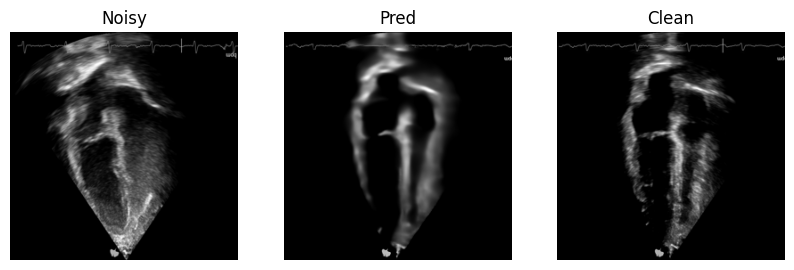

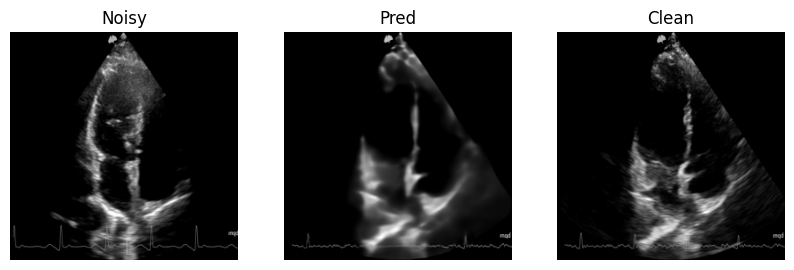

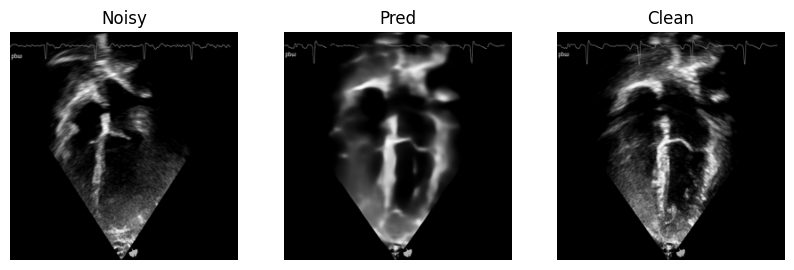

In [ ]:
# Visualize a sample prediction from validation set (if trained)
@torch.no_grad()
def show_val_samples(model, loader, n=3):
    model.eval()
    cnt = 0
    for noisy, clean in loader:
        noisy = noisy.to(device)
        clean = clean.to(device)
        pred = model(noisy)
        B = noisy.size(0)
        for i in range(B):
            if cnt >= n:
                return
            fig, axs = plt.subplots(1,3, figsize=(10,3))
            axs[0].imshow(tensor_to_img(noisy[i]), cmap='gray'); axs[0].set_title('Noisy'); axs[0].axis('off')
            axs[1].imshow(tensor_to_img(pred[i]), cmap='gray'); axs[1].set_title('Pred'); axs[1].axis('off')
            axs[2].imshow(tensor_to_img(clean[i]), cmap='gray'); axs[2].set_title('Clean'); axs[2].axis('off')
            plt.show()
            cnt += 1

if 'best_path' in globals() and os.path.isfile(best_ckpt):
    mdl = load_checkpoint(best_ckpt)
    show_val_samples(mdl, val_loader, n=3)
else:
    print('Train and create a best checkpoint to visualize predictions.')